<a href="https://colab.research.google.com/github/brentmutetwa/credit-risk-classifier/blob/main/credit_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Data Loading

In [88]:
#reading data into dataframe "customers"
customers = pd.read_csv("german_credit_data.csv")
customers

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


Exploratory Data Analysis

In [89]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


We can se that there are missing values in the "Savings accounts" and "Checking account" columns, close to 20% for the former and 40% for the latter. Let's visualise the distributions to see how we can handle the missing data.

<Axes: >

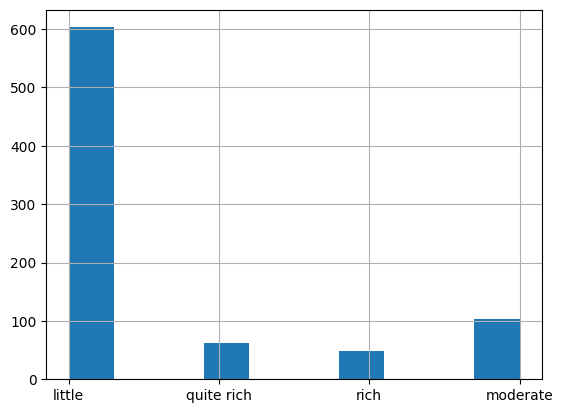

In [90]:
customers['Saving accounts'].hist()

<Axes: >

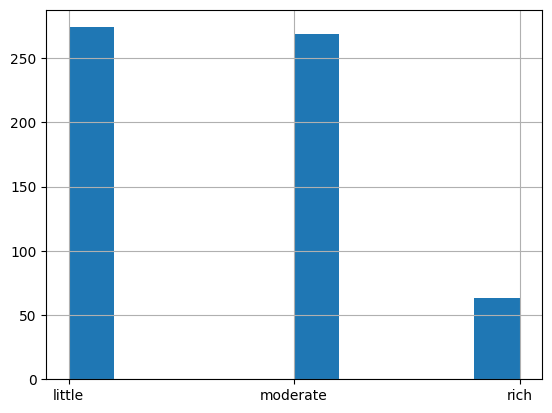

In [91]:
customers["Checking account"].hist()

In [92]:
customers.drop(columns="Checking account", inplace=True)
customers['Saving accounts'] = customers['Saving accounts'].fillna("little")
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       1000 non-null   int64 
 1   Age              1000 non-null   int64 
 2   Sex              1000 non-null   object
 3   Job              1000 non-null   int64 
 4   Housing          1000 non-null   object
 5   Saving accounts  1000 non-null   object
 6   Credit amount    1000 non-null   int64 
 7   Duration         1000 non-null   int64 
 8   Purpose          1000 non-null   object
 9   Risk             1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [93]:
customers.nunique()

,0
Unnamed: 0,1000
Age,53
Sex,2
Job,4
Housing,3
Saving accounts,4
Credit amount,921
Duration,33
Purpose,8
Risk,2


In [94]:
columns = ["Sex", "Job", "Housing", "Saving accounts", "Purpose", "Risk"]

for col in columns:
  print(str(col) + ": " + str(customers[col].unique()))

Sex: ['male' 'female']
Job: [2 1 3 0]
Housing: ['own' 'free' 'rent']
Saving accounts: ['little' 'quite rich' 'rich' 'moderate']
Purpose: ['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']
Risk: ['good' 'bad']


We can use binary coding for "Sex" since there are only 2 values the variable can take, integer encoding for "Housing", "Saving accounts", "Checking account" and "Purpose" since they are all ordinal. "Risk" is our target variable.

In [95]:
#drop "Unamed: 0" column
customers.drop(columns=["Unnamed: 0"], inplace=True)
customers

,Age,Sex,Job,Housing,Saving accounts,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,little,1169,6,radio/TV,good
1,22,female,2,own,little,5951,48,radio/TV,bad
2,49,male,1,own,little,2096,12,education,good
3,45,male,2,free,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,1736,12,furniture/equipment,good
996,40,male,3,own,little,3857,30,car,good
997,38,male,2,own,little,804,12,radio/TV,good
998,23,male,2,free,little,1845,45,radio/TV,bad


In [96]:
customers.rename(columns={
    'Saving accounts': 'Savings_account',
    'Credit amount': 'Credit_amount'
}, inplace=True)

In [97]:
#calculate risk counts amount per purpose to determine ranking
purpose_risk = customers.groupby('Purpose')['Risk'].value_counts(normalize=True).unstack()
print(purpose_risk)

Risk                      bad      good
Purpose                                
business             0.350515  0.649485
car                  0.314540  0.685460
domestic appliances  0.333333  0.666667
education            0.389831  0.610169
furniture/equipment  0.320442  0.679558
radio/TV             0.221429  0.778571
repairs              0.363636  0.636364
vacation/others      0.416667  0.583333


In [98]:
from pandas.api.types import CategoricalDtype

housing_order = CategoricalDtype(categories=['free', 'rent', 'own'], ordered=True)
customers['Housing'] = customers['Housing'].astype(housing_order).cat.codes

savings_account_order = CategoricalDtype(categories=["little", "moderate", "rich", "quite rich"], ordered=True)
customers['Savings_account'] = customers['Savings_account'].astype(savings_account_order).cat.codes

purpose_order = CategoricalDtype(categories=["business", "car", "domestic appliances", "education", "furniture/equipment", "radio/TV", "repairs", "vacation/others"], ordered=True)
customers['Purpose'] = customers['Purpose'].astype(purpose_order).cat.codes

customers

,Age,Sex,Job,Housing,Savings_account,Credit_amount,Duration,Purpose,Risk
0,67,male,2,2,0,1169,6,5,good
1,22,female,2,2,0,5951,48,5,bad
2,49,male,1,2,0,2096,12,3,good
3,45,male,2,0,0,7882,42,4,good
4,53,male,2,0,0,4870,24,1,bad
...,...,...,...,...,...,...,...,...,...
995,31,female,1,2,0,1736,12,4,good
996,40,male,3,2,0,3857,30,1,good
997,38,male,2,2,0,804,12,5,good
998,23,male,2,0,0,1845,45,5,bad


In [105]:
#binary coding "sex" and "risk" variables
customers["Sex"] = customers["Sex"].apply(lambda x: 1 if x=="male" else 0)
customers["Risk"] = customers["Risk"].apply(lambda x: 1 if x=="good" else 0)

customers

,Age,Sex,Job,Housing,Savings_account,Credit_amount,Duration,Purpose,Risk
0,67,1,2,2,0,1169,6,5,1
1,22,0,2,2,0,5951,48,5,0
2,49,1,1,2,0,2096,12,3,1
3,45,1,2,0,0,7882,42,4,1
4,53,1,2,0,0,4870,24,1,0
...,...,...,...,...,...,...,...,...,...
995,31,0,1,2,0,1736,12,4,1
996,40,1,3,2,0,3857,30,1,1
997,38,1,2,2,0,804,12,5,1
998,23,1,2,0,0,1845,45,5,0


In [107]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              1000 non-null   int64
 1   Sex              1000 non-null   int64
 2   Job              1000 non-null   int64
 3   Housing          1000 non-null   int8 
 4   Savings_account  1000 non-null   int8 
 5   Credit_amount    1000 non-null   int64
 6   Duration         1000 non-null   int64
 7   Purpose          1000 non-null   int8 
 8   Risk             1000 non-null   int64
dtypes: int64(6), int8(3)
memory usage: 49.9 KB


In [108]:
X = customers.drop(columns=["Risk"])
y = customers["Risk"]

In [110]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30)

In [111]:
#create and train a RF classifier
model = RandomForestClassifier(n_estimators=100, random_state=30)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=30)

In [112]:
#generate predictions
y_pred = model.predict(X_test)

In [117]:
accuracy = accuracy_score(y_test, y_pred)
round(accuracy, 2)

0.69

In [118]:
from sklearn.metrics import confusion_matrix

#assuming y_test contains actual labels and y_pred the predicted ones
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 24,  74],
       [ 20, 182]])

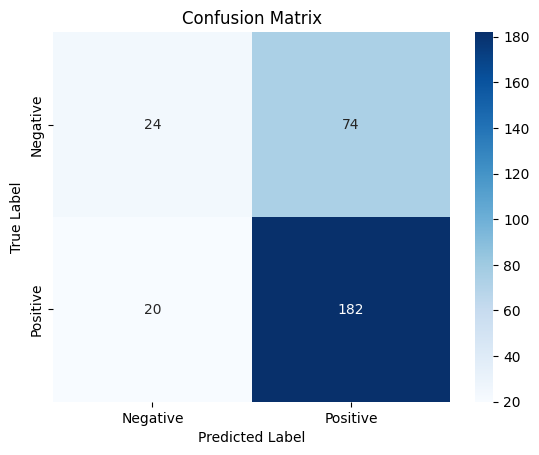

In [120]:
import seaborn as sns

#plotting the confusion matrix with labels
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [142]:
feature_imp = pd.DataFrame(pd.Series(model.feature_importances_, index = X_train.columns.values).sort_values(ascending=False))

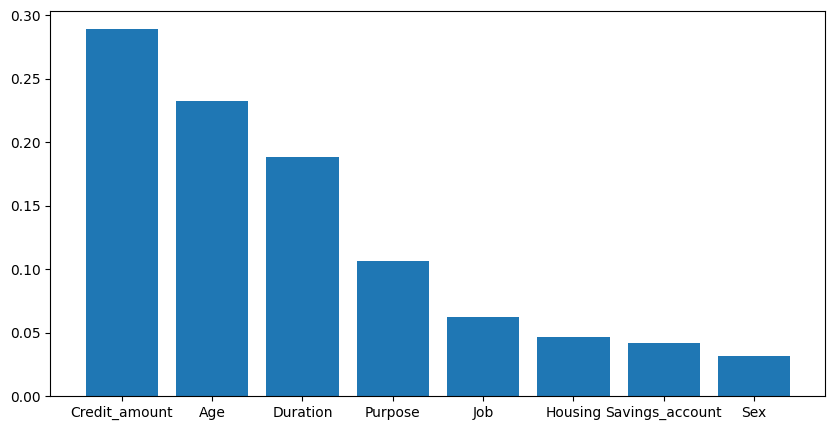

In [149]:
plt.figure(figsize=(10,5))
plt.bar(feature_imp.index, feature_imp.iloc[:, 0])
plt.show()